# AlphaEarth × SACP+GeoCP — Land Cover Classification Pilot

**Goal**: take Google's AlphaEarth 64-band foundation model embeddings, train an XGBoost land-cover classifier on a small region, and apply spatial conformal prediction (SACP+GeoCP) to obtain per-pixel uncertainty with marginal coverage guarantee.

**Data**:
- AlphaEarth Foundation embeddings (`GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL`), 64 bands @ 10m resolution, year 2020.
- ESA WorldCover v100 land cover (11 classes), mode-aggregated from 10m to 100m to match.

**Spatial design**:
- 10 small dense raster tiles (10 km × 10 km @ 100m = ~100×100 = 10,000 pixels each).
- All pixels in each tile (no sampling).
- Tiles span diverse US ecoregions (Iowa cropland, FL wetland, TX semi-arid, CA Central Valley, etc.).

**Pipeline per tile**:
1. Pull AlphaEarth + ESA WorldCover from Earth Engine.
2. Filter to labeled pixels, stratified 60/20/20 train/calib/test split.
3. Train XGBoost classifier on 64 AE embeddings → softmax probabilities.
4. Apply five CP variants: Standard CP, SACP(λ∈{0.3,0.5,0.7}), SACP+GeoCP (CV bandwidth).
5. Save per-tile checkpoint with full prediction sets, local thresholds, and metrics.

**Robustness**:
- Per-tile checkpointing — interrupt and resume safely.
- Atomic writes with `os.replace`.
- Skip tiles whose pickle already exists.

**Output**: aggregated summary across tiles (mean coverage, IS, paired tests) + qualitative figures.

Run cells in order. The first run takes ~10 minutes; re-runs are seconds.

## 1. Setup — install dependencies and authenticate

In [ ]:
# Install all dependencies. geocp_rs comes from the GitHub repo.
!pip install -q earthengine-api geemap xgboost scikit-learn matplotlib pandas
!pip install -q git+https://github.com/pengtum/GeoCP_RS.git

import sys, os, time, json, pickle, gc
print('Python:', sys.version.split()[0])
print('Packages installed.')


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Python: 3.12.13
Packages installed.


## 2. Mount Drive + authenticate Earth Engine

In [ ]:
# Drive — for persistent storage of pulled tiles + per-tile checkpoints
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

# ★ NATIVE 10m: separate working directory so the previous 100m results
# are preserved. We keep the same tile bounding boxes so the geographic
# coverage is identical; only the resolution changes.
WORK_DIR = '/content/drive/MyDrive/alphaearth_landcover_pilot_10m'
TILE_DIR = f'{WORK_DIR}/tiles'        # raw tile .npz files
CKPT_DIR = f'{WORK_DIR}/checkpoints'  # per-tile SACP+GeoCP results
RESULTS_DIR = f'{WORK_DIR}/results'   # aggregated JSON / CSV
FIG_DIR = f'{WORK_DIR}/figures'       # paper-ready plots
# Drive folder where Export.image.toDrive will write intermediate GeoTIFFs.
# Must be a PLAIN folder name under MyDrive — not a full path.
EXPORT_DRIVE_FOLDER = 'alphaearth_landcover_pilot_10m_tif'

for d in [WORK_DIR, TILE_DIR, CKPT_DIR, RESULTS_DIR, FIG_DIR]:
    os.makedirs(d, exist_ok=True)
print(f'WORK_DIR: {WORK_DIR}')

# Earth Engine — reuse the same authenticated project from before
import ee
PROJECT_ID = 'myproject-alpha-earth'  # your GEE-enabled project ID
try:
    ee.Initialize(project=PROJECT_ID)
    print('Earth Engine initialized')
except Exception:
    ee.Authenticate()
    ee.Initialize(project=PROJECT_ID)
    print('Earth Engine authenticated and initialized')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
WORK_DIR: /content/drive/MyDrive/alphaearth_landcover_pilot_10m
Earth Engine initialized


## 3. Define the 10 tiles (diverse US ecoregions)

In [ ]:
# Each tile is a ~10 km × 10 km bounding box (lon_min, lat_min, lon_max, lat_max).
# Areas were chosen to span different land-cover mixes:
#   IP-style cropland-dominant, urban-dominant, wetland-dominant, semi-arid, etc.

TILES = {
    'polk_iowa':       dict(name='Polk County, Iowa',      bbox=[-93.66, 41.55, -93.55, 41.65]),
    'lancaster_pa':    dict(name='Lancaster, PA',          bbox=[-76.36, 39.99, -76.25, 40.09]),
    'hartford_ct':     dict(name='Hartford, CT',           bbox=[-72.74, 41.74, -72.63, 41.84]),
    'everglades_fl':   dict(name='Everglades, FL',         bbox=[-80.75, 25.75, -80.64, 25.85]),
    'lubbock_tx':      dict(name='Lubbock, TX',            bbox=[-101.95, 33.55, -101.84, 33.65]),
    'sacramento_ca':   dict(name='Sacramento Valley, CA',  bbox=[-121.45, 38.65, -121.34, 38.75]),
    'phoenix_az':      dict(name='Phoenix, AZ',            bbox=[-112.15, 33.45, -112.04, 33.55]),
    'yellowstone_wy':  dict(name='Yellowstone edge, WY',   bbox=[-110.55, 44.45, -110.44, 44.55]),
    'seattle_wa':      dict(name='Seattle, WA',            bbox=[-122.35, 47.55, -122.24, 47.65]),
    'mississippi_la':  dict(name='Mississippi Delta, LA',  bbox=[-91.55, 30.95, -91.44, 31.05]),
}
print(f'{len(TILES)} tiles configured')
for k, v in TILES.items():
    lon_min, lat_min, lon_max, lat_max = v['bbox']
    w_km = (lon_max - lon_min) * 111 * 0.78  # rough at mid-lat
    h_km = (lat_max - lat_min) * 111
    print(f'  {k:18s} — {v["name"]:25s}  ~{w_km:.1f}×{h_km:.1f} km')


10 tiles configured
  polk_iowa          — Polk County, Iowa          ~9.5×11.1 km
  lancaster_pa       — Lancaster, PA              ~9.5×11.1 km
  hartford_ct        — Hartford, CT               ~9.5×11.1 km
  everglades_fl      — Everglades, FL             ~9.5×11.1 km
  lubbock_tx         — Lubbock, TX                ~9.5×11.1 km
  sacramento_ca      — Sacramento Valley, CA      ~9.5×11.1 km
  phoenix_az         — Phoenix, AZ                ~9.5×11.1 km
  yellowstone_wy     — Yellowstone edge, WY       ~9.5×11.1 km
  seattle_wa         — Seattle, WA                ~9.5×11.1 km
  mississippi_la     — Mississippi Delta, LA      ~9.5×11.1 km


## 4. Pull AlphaEarth + ESA WorldCover for each tile
Each tile takes ~30 seconds on first run. Cached on Drive thereafter.

In [ ]:
import numpy as np
import ee, time

# rasterio comes pre-installed in Colab; install if missing
try:
    import rasterio
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', '-q', 'rasterio'], check=True)
    import rasterio


SCALE_M = 10   # ★ native AlphaEarth resolution


def submit_export_task(tile_key):
    """Submit an Export.image.toDrive task and return (task, band_names)."""
    bbox = TILES[tile_key]['bbox']
    aoi = ee.Geometry.Rectangle(bbox)

    col = (ee.ImageCollection('GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL')
             .filterDate('2020-01-01', '2021-01-01'))
    # AlphaEarth bands are Float64; ESA WorldCover is Byte. Export.image.toDrive
    # requires compatible dtypes across all bands, so we cast both to Float32.
    emb = col.mosaic().toFloat()
    band_names = emb.bandNames().getInfo()

    esa = ee.Image('ESA/WorldCover/v100/2020').select('Map').rename('label').toFloat()
    stack = emb.addBands(esa)

    task = ee.batch.Export.image.toDrive(
        image=stack,
        description=f'ae_10m_{tile_key}',
        folder=EXPORT_DRIVE_FOLDER,
        fileNamePrefix=tile_key,
        region=aoi,
        scale=SCALE_M,
        crs='EPSG:4326',
        maxPixels=int(1e9),
        fileFormat='GeoTIFF',
    )
    task.start()
    return task, band_names


def _tif_path(tile_key):
    return f'/content/drive/MyDrive/{EXPORT_DRIVE_FOLDER}/{tile_key}.tif'


def geotiff_to_npz(tile_key):
    """Read the exported GeoTIFF into (emb, label) numpy arrays and cache to npz."""
    out_path = f'{TILE_DIR}/{tile_key}.npz'
    if os.path.exists(out_path):
        arr = np.load(out_path)
        return arr['emb'], arr['label']

    tif_path = _tif_path(tile_key)
    if not os.path.exists(tif_path):
        raise FileNotFoundError(f'Exported GeoTIFF not found: {tif_path}. '
                                 'Has the Export task finished?')

    with rasterio.open(tif_path) as src:
        arr = src.read()   # (bands, H, W)
    arr = arr.transpose(1, 2, 0)  # (H, W, bands)
    emb_np = arr[:, :, :64].astype(np.float32)
    label_np = arr[:, :, 64].astype(np.int16)

    tmp = out_path + '.tmp'
    with open(tmp, 'wb') as fh:
        np.savez_compressed(fh, emb=emb_np, label=label_np)
    os.replace(tmp, out_path)
    return emb_np, label_np


def pull_tile(tile_key, force=False):
    """Pull one tile at 10m native: submit Export task, wait, read GeoTIFF."""
    out_path = f'{TILE_DIR}/{tile_key}.npz'
    if os.path.exists(out_path) and not force:
        arr = np.load(out_path)
        return arr['emb'], arr['label']

    task, _ = submit_export_task(tile_key)
    print(f'  {tile_key}: export task submitted, polling...')
    while task.active():
        time.sleep(30)
        print(f'    still running...')
    state = task.status().get('state', 'UNKNOWN')
    if state != 'COMPLETED':
        raise RuntimeError(f'{tile_key}: task {state}: {task.status()}')
    return geotiff_to_npz(tile_key)


# Test on one tile first — this will take ~1-3 minutes for the first one
print('Test pull (10m native): polk_iowa')
t0 = time.time()
emb, lab = pull_tile('polk_iowa')
print(f'  shape: emb={emb.shape}, label={lab.shape}')
print(f'  {(lab > 0).sum()} labeled pixels  [{time.time()-t0:.0f}s]')
print(f'  unique labels: {sorted(np.unique(lab).tolist())}')
unique, counts = np.unique(lab, return_counts=True)
print(f'  pixels per class: {dict(zip(unique.tolist(), counts.tolist()))}')


Test pull (10m native): polk_iowa
  shape: emb=(1114, 1226, 64), label=(1114, 1226)
  1365764 labeled pixels  [2s]
  unique labels: [10, 30, 40, 50, 60, 80, 90]
  pixels per class: {10: 537099, 30: 256325, 40: 41813, 50: 411320, 60: 68781, 80: 50353, 90: 73}


In [ ]:
# Pull the remaining 9 tiles. We submit all export tasks in parallel so
# GEE can run them concurrently on its backend, then poll and read them back
# as each completes. Cached tiles are skipped.
import time

# Submit phase
pending = {}
for tile_key in TILES:
    if os.path.exists(f'{TILE_DIR}/{tile_key}.npz'):
        sz_kb = os.path.getsize(f'{TILE_DIR}/{tile_key}.npz') // 1024
        print(f'  [cached] {tile_key:18s} ({sz_kb} KB)')
        continue
    tif_path = _tif_path(tile_key)
    if os.path.exists(tif_path):
        print(f'  [tif exists, converting] {tile_key}')
        geotiff_to_npz(tile_key)
        continue
    task, _ = submit_export_task(tile_key)
    pending[tile_key] = task
    print(f'  [submitted] {tile_key}')

# Poll phase
t0 = time.time()
while pending:
    time.sleep(30)
    done = []
    for tk, task in list(pending.items()):
        state = task.status().get('state', 'UNKNOWN')
        if state == 'COMPLETED':
            try:
                emb, lab = geotiff_to_npz(tk)
                n = int((lab > 0).sum())
                ncls = int(len(np.unique(lab[lab > 0])))
                print(f'  [done] {tk:18s} shape={emb.shape}, {n} labeled px, {ncls} classes')
            except Exception as e:
                print(f'  [convert failed] {tk}: {e}')
            done.append(tk)
        elif state in ('FAILED', 'CANCELLED'):
            print(f'  [{state}] {tk}: {task.status().get("error_message", "")}')
            done.append(tk)
    for tk in done:
        del pending[tk]
    if pending:
        print(f'  ... {len(pending)} remaining  [{time.time()-t0:.0f}s elapsed]')

print(f'\nAll tiles ready. Total time: {(time.time()-t0)/60:.1f} min')


  [cached] polk_iowa          (89068 KB)
  [cached] lancaster_pa       (91388 KB)
  [cached] hartford_ct        (89622 KB)
  [cached] everglades_fl      (98850 KB)
  [cached] lubbock_tx         (95110 KB)
  [cached] sacramento_ca      (90522 KB)
  [cached] phoenix_az         (97681 KB)
  [cached] yellowstone_wy     (76942 KB)
  [cached] seattle_wa         (72668 KB)
  [cached] mississippi_la     (98350 KB)

All tiles ready. Total time: 0.0 min


## 5. Per-tile pipeline — XGBoost + SACP+GeoCP

For each tile: stratified 60/20/20 split, train XGBoost on 64 AE embeddings, then run all five CP variants. Results pickled per tile.

In [ ]:
"""Per-tile pipeline for 10m native data.

At 10m each tile has ~1M pixels. SACP smoothing runs on the full grid
(cheap, O(HW*K) convolution). GeoCP requires a pairwise distance matrix
which would be ~200K x 200K = prohibitive. We therefore subsample the
calibration and test sets to a tractable size (default 5K/10K) for GeoCP
evaluation, while keeping the SACP smoothing on the full grid.

All CP methods are evaluated on the SAME subsampled test set for a fair
comparison.
"""
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split, KFold
from scipy.spatial.distance import cdist
from collections import Counter

from geocp_rs.core import aps_scores, conformal_quantile, weighted_quantile
from geocp_rs.sacp import sacp_smooth
from geocp_rs.metrics import coverage_and_size, interval_score


def run_one_tile(tile_key, seed=0, max_cal=5000, max_test=10000,
                 lmd=0.5, alpha=0.1, force=False,
                 bw_grid=(3, 5, 10, 30, 100, 300, 1000)):
    """Train XGBoost + SACP + GeoCP (with GeoCP subsampling)."""
    ckpt_path = f'{CKPT_DIR}/{tile_key}_seed{seed}.pkl'
    if os.path.exists(ckpt_path) and not force:
        with open(ckpt_path, 'rb') as f:
            return pickle.load(f)

    # ---- Load tile ----
    arr = np.load(f'{TILE_DIR}/{tile_key}.npz')
    emb = arr['emb']; label = arr['label']
    H, W, _ = emb.shape
    N = H * W
    flat_label = label.ravel()
    X_flat = emb.reshape(N, 64)

    # ---- Filter labeled pixels and remap rare classes ----
    labeled_idx = np.where(flat_label > 0)[0]
    y_raw = flat_label[labeled_idx]
    counts = Counter(y_raw.tolist())
    rare = [c for c, cnt in counts.items() if cnt < 100]
    keep = ~np.isin(y_raw, rare)
    labeled_idx = labeled_idx[keep]
    y_raw = y_raw[keep]
    X_lab = X_flat[labeled_idx]
    classes = sorted(np.unique(y_raw).tolist())
    K = len(classes)
    if K < 2:
        raise RuntimeError(f'{tile_key}: only {K} class after rare filter')
    cls_remap = {c: i for i, c in enumerate(classes)}
    y = np.array([cls_remap[v] for v in y_raw])

    # ---- 60/20/20 stratified split ----
    idx_pos = np.arange(len(y))
    idx_tr, idx_tmp = train_test_split(
        idx_pos, train_size=0.6, random_state=seed*100+42, stratify=y)
    idx_ca, idx_te = train_test_split(
        idx_tmp, test_size=0.5, random_state=seed*100+42, stratify=y[idx_tmp])

    # ---- Train XGBoost ----
    model = xgb.XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        objective='multi:softprob', num_class=K,
        tree_method='hist', random_state=seed*100+42, verbosity=0)
    model.fit(X_lab[idx_tr], y[idx_tr])
    probs_ca = model.predict_proba(X_lab[idx_ca])
    probs_te = model.predict_proba(X_lab[idx_te])
    pred_te = np.argmax(probs_te, axis=1)
    acc = float(np.mean(pred_te == y[idx_te]))

    # ---- APS nonconformity scores ----
    rng = np.random.RandomState(seed*100+42)
    cal_all = aps_scores(probs_ca, rng=rng)
    test_all = aps_scores(probs_te, rng=rng)
    cal_true = aps_scores(probs_ca, y[idx_ca], rng=rng)

    # ---- SACP smoothing on the full grid ----
    cal_flat_idx = labeled_idx[idx_ca]
    test_flat_idx = labeled_idx[idx_te]

    score_map = np.zeros((N, K), dtype=np.float64)
    score_map[cal_flat_idx] = cal_all
    score_map[test_flat_idx] = test_all
    valid_idx = np.concatenate([cal_flat_idx, test_flat_idx])
    fused = sacp_smooth(score_map, H, W, valid_idx, lmd=lmd)

    # Smoothed scores at cal-true-labels and full test row
    fcu = np.array([fused[cal_flat_idx[e], int(y[idx_ca[e]])]
                    for e in range(len(idx_ca))])
    ftu = fused[test_flat_idx]     # (n_test, K)

    # ---- Subsample for GeoCP evaluation (stratified by class) ----
    def _stratified_sub(indices, labels, n):
        if n >= len(indices):
            return indices
        uniq, per_cls_counts = np.unique(labels, return_counts=True)
        per_cls_n = np.maximum(1, (n * per_cls_counts / per_cls_counts.sum()).astype(int))
        rng_sub = np.random.RandomState(seed*100+43)
        out = []
        for c, nc in zip(uniq, per_cls_n):
            pool = np.where(labels == c)[0]
            if len(pool) <= nc:
                out.append(pool)
            else:
                out.append(rng_sub.choice(pool, size=nc, replace=False))
        return np.concatenate(out)

    sub_ca = _stratified_sub(np.arange(len(idx_ca)), y[idx_ca], max_cal)
    sub_te = _stratified_sub(np.arange(len(idx_te)), y[idx_te], max_test)

    # Standard / SACP / SACP+GeoCP ALL evaluated on the SAME subsampled test set
    y_te_sub = y[idx_te][sub_te]
    test_all_sub = test_all[sub_te]
    ftu_sub = ftu[sub_te]

    # ---- Standard CP ----
    q_std = conformal_quantile(cal_true, alpha)
    ps_std = [np.where(test_all_sub[i] < q_std)[0].tolist()
              for i in range(len(sub_te))]
    cov_std, sz_std = coverage_and_size(ps_std, y_te_sub)
    is_std = interval_score(ps_std, y_te_sub, alpha)

    # ---- SACP (global quantile on smoothed cal) ----
    q_sacp = conformal_quantile(fcu, alpha)
    ps_sacp = [np.where(ftu_sub[i] < q_sacp)[0].tolist()
               for i in range(len(sub_te))]
    cov_sacp, sz_sacp = coverage_and_size(ps_sacp, y_te_sub)
    is_sacp = interval_score(ps_sacp, y_te_sub, alpha)

    # ---- SACP+GeoCP: CV bandwidth selection on subsampled cal, then eval ----
    fcu_sub = fcu[sub_ca]
    y_ca_sub = y[idx_ca][sub_ca]
    coords_ca_sub = np.stack(
        [cal_flat_idx[sub_ca] // W, cal_flat_idx[sub_ca] % W], axis=1).astype(float)
    coords_te_sub = np.stack(
        [test_flat_idx[sub_te] // W, test_flat_idx[sub_te] % W], axis=1).astype(float)

    # CV on cal_sub to pick bandwidth
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_is = {bw: [] for bw in bw_grid}
    for f_tr, f_val in kf.split(np.arange(len(sub_ca))):
        fcu_tr = fcu_sub[f_tr]
        # val nonconformity scores on all classes (from the already-smoothed grid)
        val_global = cal_flat_idx[sub_ca[f_val]]
        fcu_val_all = fused[val_global]     # (n_val, K)
        y_cv_val = y_ca_sub[f_val]
        d_cv = cdist(coords_ca_sub[f_val], coords_ca_sub[f_tr])
        for bw in bw_grid:
            ps_cv = []
            for i in range(len(f_val)):
                log_w = -0.5 * (d_cv[i] / bw) ** 2
                log_w -= log_w.max()
                w = np.exp(log_w)
                q = weighted_quantile(fcu_tr, w, alpha)
                ps_cv.append(np.where(fcu_val_all[i] < q)[0].tolist())
            cv_is[bw].append(interval_score(ps_cv, y_cv_val, alpha))
    best_bw = int(min(bw_grid, key=lambda b: np.mean(cv_is[b])))

    # Final GeoCP evaluation on full subsampled test
    d_final = cdist(coords_te_sub, coords_ca_sub)
    ps_gc = []
    q_per_pixel = np.empty(len(sub_te))
    for j in range(len(sub_te)):
        log_w = -0.5 * (d_final[j] / best_bw) ** 2
        log_w -= log_w.max()
        w = np.exp(log_w)
        q = weighted_quantile(fcu_sub, w, alpha)
        q_per_pixel[j] = q
        ps_gc.append(np.where(ftu_sub[j] < q)[0].tolist())
    cov_gc, sz_gc = coverage_and_size(ps_gc, y_te_sub)
    is_gc = interval_score(ps_gc, y_te_sub, alpha)

    # ---- Pack result ----
    result = {
        'tile_key': tile_key,
        'tile_name': TILES[tile_key]['name'],
        'seed': int(seed),
        'h': int(H), 'w': int(W),
        'scale_m': int(SCALE_M),
        'n_labeled': int(len(labeled_idx)),
        'n_train': int(len(idx_tr)),
        'n_calib': int(len(idx_ca)),
        'n_test': int(len(idx_te)),
        'n_cal_sub': int(len(sub_ca)),
        'n_test_sub': int(len(sub_te)),
        'n_classes': int(K),
        'esa_class_codes': classes,
        'accuracy': acc,
        'standard_cp': {'cov': cov_std, 'size': sz_std, 'is': is_std, 'pred_sets': ps_std},
        'sacp_0.5':    {'cov': cov_sacp, 'size': sz_sacp, 'is': is_sacp, 'pred_sets': ps_sacp},
        'sacp_geocp':  {'cov': cov_gc, 'size': sz_gc, 'is': is_gc,
                        'bw': best_bw, 'pred_sets': ps_gc,
                        'q_per_pixel': q_per_pixel.tolist(),
                        'cv_is_mean': {int(bw): float(np.mean(cv_is[bw])) for bw in bw_grid}},
        # for viz
        'cal_sub_flat_idx':  cal_flat_idx[sub_ca].tolist(),
        'test_sub_flat_idx': test_flat_idx[sub_te].tolist(),
        'y_cal_sub':  y_ca_sub.tolist(),
        'y_test_sub': y_te_sub.tolist(),
    }

    tmp = ckpt_path + '.tmp'
    with open(tmp, 'wb') as f:
        pickle.dump(result, f, protocol=pickle.HIGHEST_PROTOCOL)
    os.replace(tmp, ckpt_path)
    return result


# ---- Test on one tile first ----
import time
print('Test run: polk_iowa seed=0')
t0 = time.time()
r = run_one_tile('polk_iowa', seed=0)
print(f'  elapsed            = {time.time()-t0:.0f}s')
print(f'  n_labeled / split  = {r["n_labeled"]} / ({r["n_train"]}, {r["n_calib"]}, {r["n_test"]})')
print(f'  subsample          = cal {r["n_cal_sub"]} / test {r["n_test_sub"]}')
print(f'  acc                = {r["accuracy"]:.3f}')
print(f'  n_classes / codes  = {r["n_classes"]} / {r["esa_class_codes"]}')
print(f'  Standard CP        : cov={r["standard_cp"]["cov"]:.3f}  size={r["standard_cp"]["size"]:.2f}  IS={r["standard_cp"]["is"]:.3f}')
print(f'  SACP(0.5)          : cov={r["sacp_0.5"]["cov"]:.3f}  size={r["sacp_0.5"]["size"]:.2f}  IS={r["sacp_0.5"]["is"]:.3f}')
print(f'  SACP+GeoCP (bw={r["sacp_geocp"]["bw"]:>4d}) : cov={r["sacp_geocp"]["cov"]:.3f}  size={r["sacp_geocp"]["size"]:.2f}  IS={r["sacp_geocp"]["is"]:.3f}')
print(f'  CV IS per bw       : {r["sacp_geocp"]["cv_is_mean"]}')


Test run: polk_iowa seed=0
  elapsed            = 0s
  n_labeled / split  = 1365691 / (819414, 273138, 273139)
  subsample          = cal 4997 / test 9996
  acc                = 0.828
  n_classes / codes  = 6 / [10, 30, 40, 50, 60, 80]
  Standard CP        : cov=0.900  size=1.41  IS=3.404
  SACP(0.5)          : cov=0.898  size=1.27  IS=3.312
  SACP+GeoCP (bw= 300) : cov=0.904  size=1.29  IS=3.217
  CV IS per bw       : {3: 9.580350350350349, 5: 8.235738738738739, 10: 5.577154754754756, 30: 3.5379409409409406, 100: 3.3236302302302305, 300: 3.262981581581582, 1000: 3.2838076076076077}


In [ ]:
# Run all 10 tiles × 1 seed (or more)
N_SEEDS = 1   # bump to 5 or 10 for paper-quality stats

t_start = time.time()
done = 0
total = len(TILES) * N_SEEDS
for tile_key in TILES:
    for seed in range(N_SEEDS):
        ckpt = f'{CKPT_DIR}/{tile_key}_seed{seed}.pkl'
        if os.path.exists(ckpt):
            with open(ckpt, 'rb') as f:
                r = pickle.load(f)
            done += 1
            print(f'  [cached] {tile_key:18s} seed={seed}  acc={r["accuracy"]:.3f}  '
                  f'GeoCP IS={r["sacp_geocp"]["is"]:.3f}  [{done}/{total}]')
            continue
        t0 = time.time()
        try:
            r = run_one_tile(tile_key, seed=seed)
            done += 1
            print(f'  {tile_key:18s} seed={seed}  acc={r["accuracy"]:.3f}  '
                  f'GeoCP IS={r["sacp_geocp"]["is"]:.3f}  bw={r["sacp_geocp"]["bw"]}  '
                  f'[{time.time()-t0:.0f}s]  [{done}/{total}]')
        except Exception as e:
            import traceback
            print(f'  {tile_key:18s} seed={seed} FAILED: {e}')
            traceback.print_exc()

print(f'\nALL DONE in {(time.time()-t_start)/60:.1f} min')


  [cached] polk_iowa          seed=0  acc=0.828  GeoCP IS=3.217  [1/10]
  [cached] lancaster_pa       seed=0  acc=0.849  GeoCP IS=3.137  [2/10]
  [cached] hartford_ct        seed=0  acc=0.837  GeoCP IS=3.232  [3/10]
  [cached] everglades_fl      seed=0  acc=0.997  GeoCP IS=2.996  [4/10]
  [cached] lubbock_tx         seed=0  acc=0.838  GeoCP IS=3.428  [5/10]
  [cached] sacramento_ca      seed=0  acc=0.833  GeoCP IS=3.419  [6/10]
  [cached] phoenix_az         seed=0  acc=0.822  GeoCP IS=3.384  [7/10]
  [cached] yellowstone_wy     seed=0  acc=0.934  GeoCP IS=3.088  [8/10]
  [cached] seattle_wa         seed=0  acc=0.920  GeoCP IS=3.080  [9/10]
  [cached] mississippi_la     seed=0  acc=0.990  GeoCP IS=2.854  [10/10]

ALL DONE in 0.0 min


## 6. Aggregate results across tiles + statistical tests

In [ ]:
import numpy as np
import pandas as pd
import json
from scipy import stats as sstats

# Load all checkpoints
all_results = []
for tile_key in TILES:
    for seed in range(N_SEEDS):
        p = f'{CKPT_DIR}/{tile_key}_seed{seed}.pkl'
        if os.path.exists(p):
            with open(p, 'rb') as f:
                all_results.append(pickle.load(f))
print(f'Loaded {len(all_results)} per-tile-seed results')

# Build per-tile DataFrame (only sacp_0.5; the 10m pilot does not run other lambdas)
rows = []
for r in all_results:
    rows.append({
        'tile':        r['tile_key'],
        'seed':        r['seed'],
        'acc':         r['accuracy'],
        'n_classes':   r['n_classes'],
        'std_cov':     r['standard_cp']['cov'],
        'std_size':    r['standard_cp']['size'],
        'std_is':      r['standard_cp']['is'],
        'sacp05_cov':  r['sacp_0.5']['cov'],
        'sacp05_size': r['sacp_0.5']['size'],
        'sacp05_is':   r['sacp_0.5']['is'],
        'geocp_cov':   r['sacp_geocp']['cov'],
        'geocp_size':  r['sacp_geocp']['size'],
        'geocp_is':    r['sacp_geocp']['is'],
        'geocp_bw':    r['sacp_geocp']['bw'],
        'n_cal_sub':   r.get('n_cal_sub', None),
        'n_test_sub':  r.get('n_test_sub', None),
    })
df = pd.DataFrame(rows)
df.to_csv(f'{RESULTS_DIR}/per_tile.csv', index=False)
print('\n', df.to_string(index=False))

print('\n=== Aggregated stats ===')
print(f'mean acc:                  {df.acc.mean():.3f}')
print(f'mean Standard CP IS:       {df.std_is.mean():.3f}')
print(f'mean SACP(0.5) IS:         {df.sacp05_is.mean():.3f}')
print(f'mean SACP+GeoCP IS:        {df.geocp_is.mean():.3f}')
print(f'mean Standard CP coverage: {df.std_cov.mean():.3f}')
print(f'mean SACP(0.5)  coverage:  {df.sacp05_cov.mean():.3f}')
print(f'mean SACP+GeoCP coverage:  {df.geocp_cov.mean():.3f}')
print(f'mean Standard CP size:     {df.std_size.mean():.3f}')
print(f'mean SACP(0.5)  size:      {df.sacp05_size.mean():.3f}')
print(f'mean SACP+GeoCP size:      {df.geocp_size.mean():.3f}')

# Paired tests
p_geocp_vs_std = None
p_geocp_vs_sacp05 = None
if len(df) > 1:
    t1, p_geocp_vs_std = sstats.ttest_rel(df.std_is, df.geocp_is)
    print(f'\nPaired t (Std CP vs SACP+GeoCP):    t={t1:+.2f}, p={p_geocp_vs_std:.4g}')

    t2, p_geocp_vs_sacp05 = sstats.ttest_rel(df.sacp05_is, df.geocp_is)
    print(f'Paired t (SACP(0.5) vs SACP+GeoCP): t={t2:+.2f}, p={p_geocp_vs_sacp05:.4g}')

    try:
        w, pw = sstats.wilcoxon(df.sacp05_is, df.geocp_is)
        print(f'Wilcoxon (SACP(0.5) vs SACP+GeoCP): W={w:.2f}, p={pw:.4g}')
    except Exception as e:
        print(f'Wilcoxon: {e}')

    pos_vs_std    = (df.std_is    > df.geocp_is).sum()
    pos_vs_sacp05 = (df.sacp05_is > df.geocp_is).sum()
    print(f'\nGeoCP wins vs Std CP:    {pos_vs_std}/{len(df)} tiles')
    print(f'GeoCP wins vs SACP(0.5): {pos_vs_sacp05}/{len(df)} tiles')

print('\n=== Bandwidth selection ===')
for _, row in df.iterrows():
    print(f'  {row.tile:18s}  bw={int(row.geocp_bw):4d}')

# Save aggregate JSON
summary = {
    'n_tiles':        len(df),
    'mean_accuracy':  float(df.acc.mean()),
    'std_cp':         {'cov': float(df.std_cov.mean()),    'size': float(df.std_size.mean()),    'is': float(df.std_is.mean())},
    'sacp_05':        {'cov': float(df.sacp05_cov.mean()), 'size': float(df.sacp05_size.mean()), 'is': float(df.sacp05_is.mean())},
    'sacp_geocp':     {'cov': float(df.geocp_cov.mean()),  'size': float(df.geocp_size.mean()),  'is': float(df.geocp_is.mean())},
    'paired_t_p_geocp_vs_std':    float(p_geocp_vs_std) if p_geocp_vs_std is not None else None,
    'paired_t_p_geocp_vs_sacp05': float(p_geocp_vs_sacp05) if p_geocp_vs_sacp05 is not None else None,
}
with open(f'{RESULTS_DIR}/summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print(f'\n[saved] {RESULTS_DIR}/per_tile.csv')
print(f'[saved] {RESULTS_DIR}/summary.json')

Loaded 10 per-tile-seed results

           tile  seed      acc  n_classes  std_cov  std_size   std_is  sacp05_cov  sacp05_size  sacp05_is  geocp_cov  geocp_size  geocp_is  geocp_bw  n_cal_sub  n_test_sub
     polk_iowa     0 0.828212          6 0.900160  1.407563 3.404362    0.897859     1.269208   3.312025   0.903661    1.290416  3.217187       300       4997        9996
  lancaster_pa     0 0.848872          6 0.908373  1.346404 3.178954    0.904471     1.211163   3.121737   0.903571    1.208262  3.136841       300       4997        9997
   hartford_ct     0 0.836823          7 0.895848  1.407604 3.490645    0.903252     1.259430   3.194397   0.901551    1.262631  3.231616       300       4995        9995
 everglades_fl     0 0.997468          7 0.897669  0.902771 2.949385    0.899170     0.903171   2.919776   0.895169    0.899070  2.995699       300       4996        9997
    lubbock_tx     0 0.838103          7 0.898370  1.338201 3.370811    0.899470     1.218666   3.229269   0.88

## 7. Figures — qualitative 4-panel grid + IS bar chart

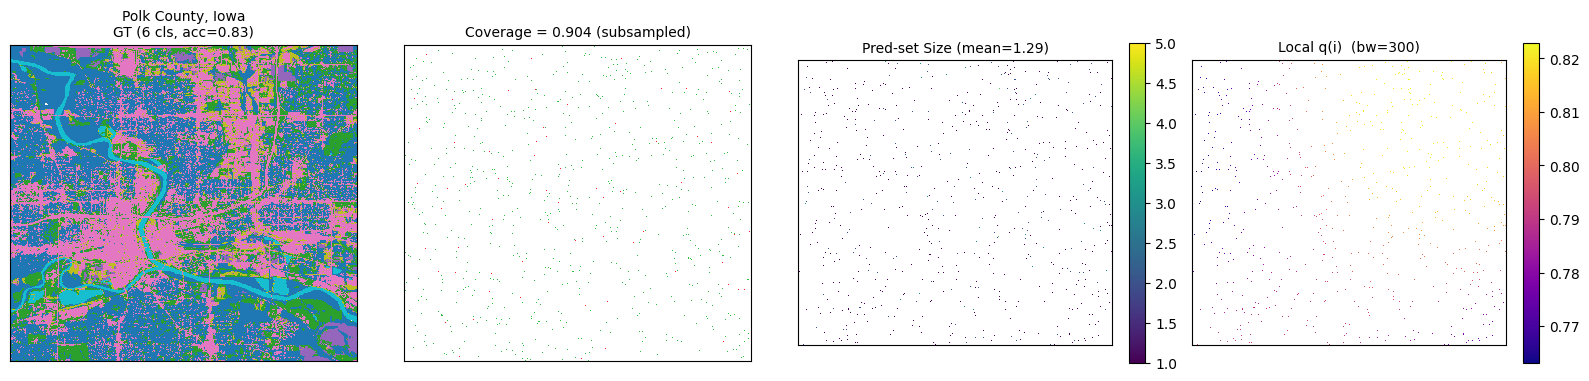

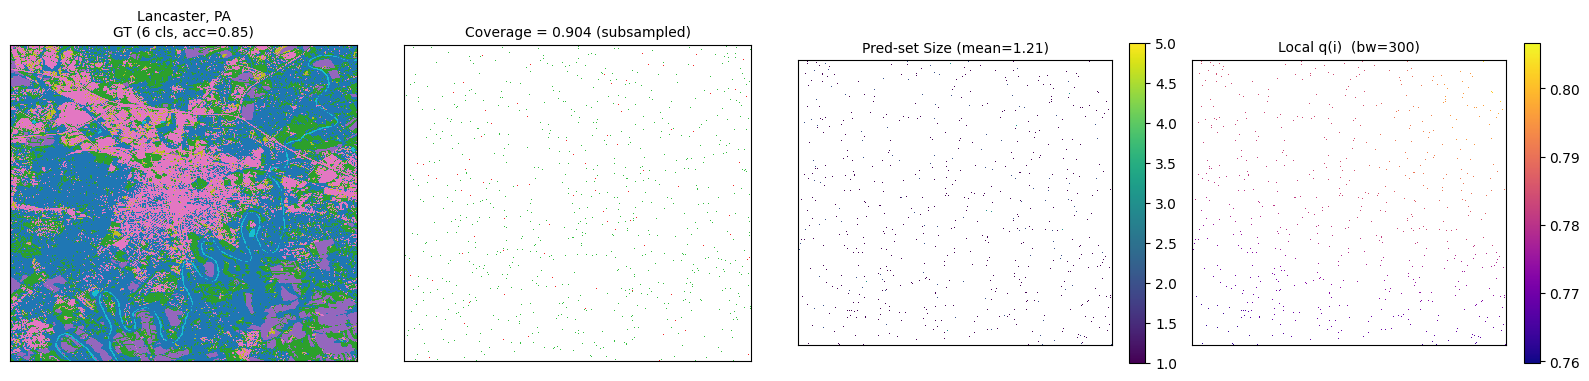

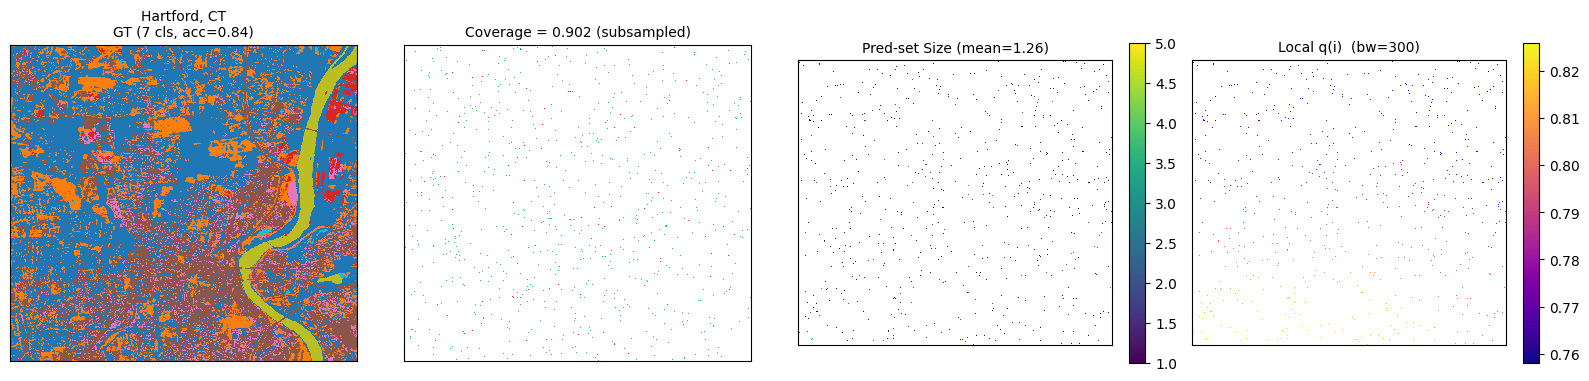

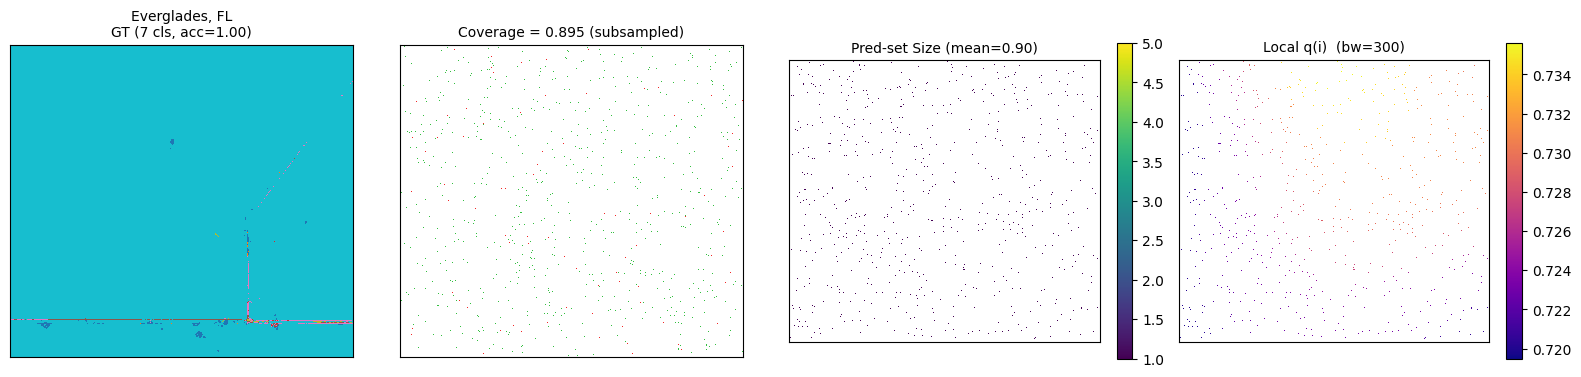

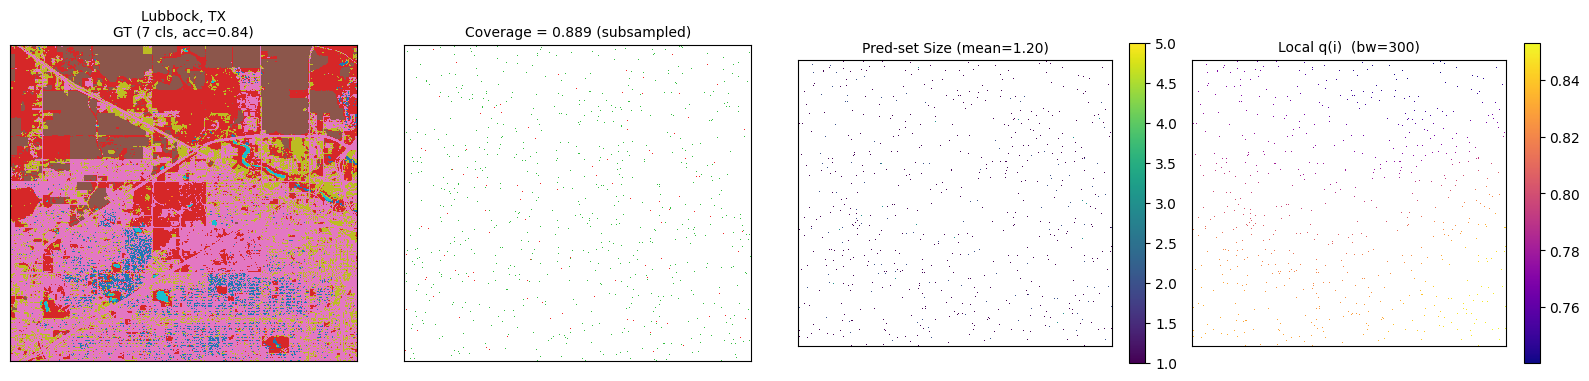

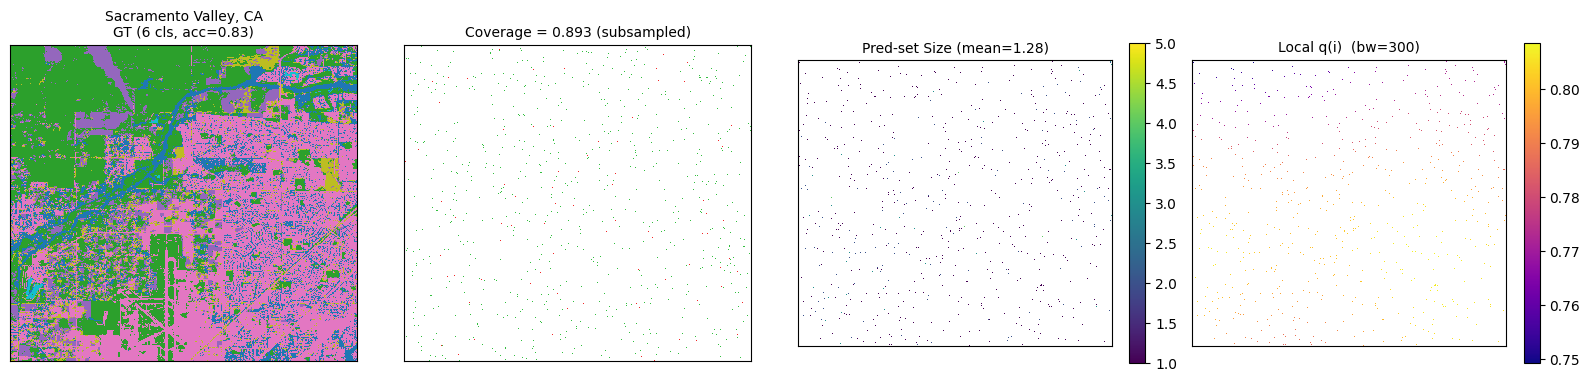

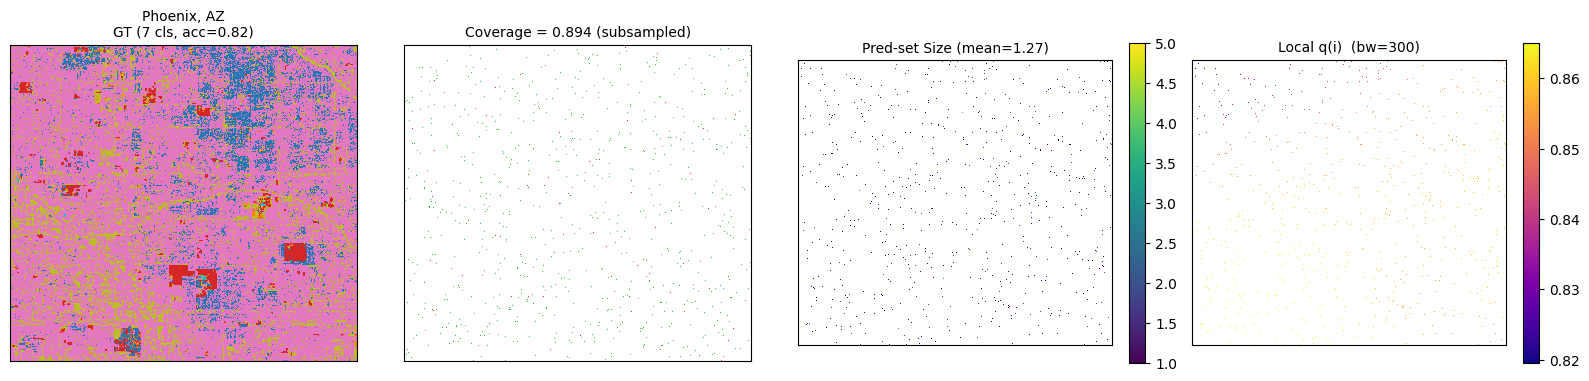

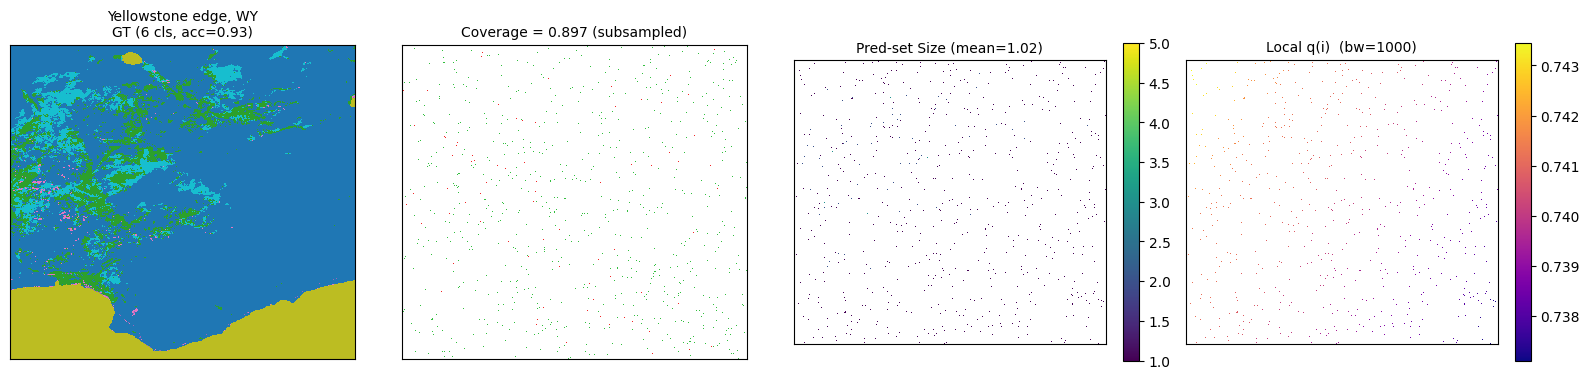

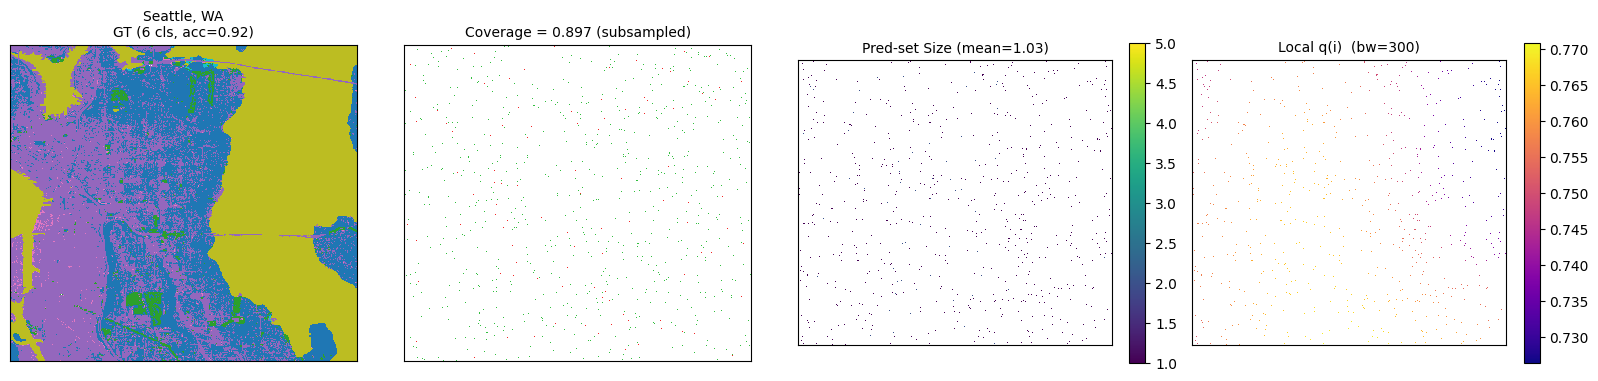

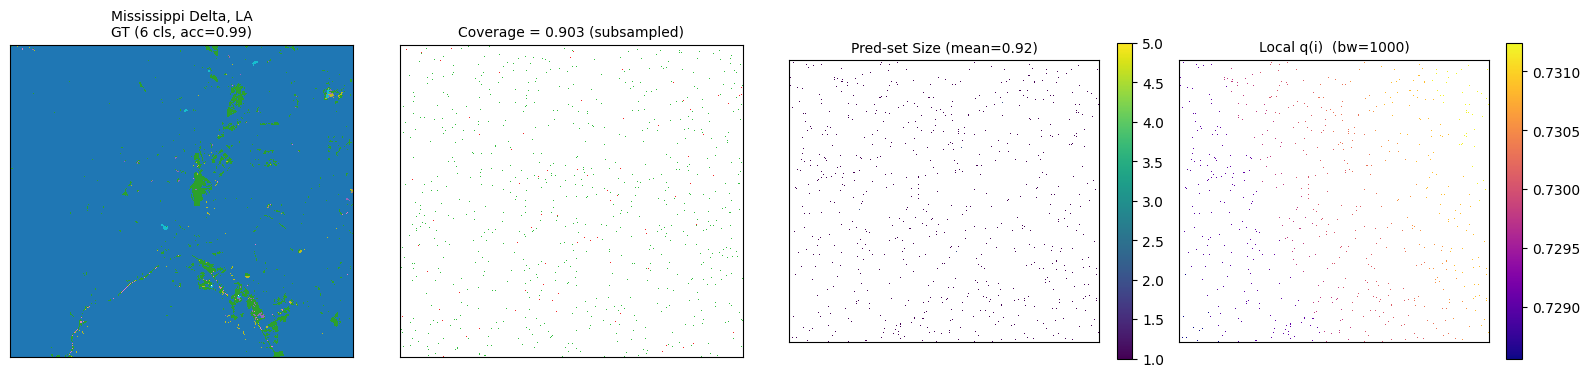

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

ESA_NAMES = {10:'Tree', 20:'Shrub', 30:'Grass', 40:'Crop', 50:'Built',
              60:'Bare', 70:'Snow', 80:'Water', 90:'Wetland', 95:'Mangrove', 100:'Moss'}


def plot_qualitative(tile_key, seed=0, save=True):
    """4-panel qualitative figure: GT label / coverage / size / local q.

    Note: for 10m pilot, GeoCP is evaluated on a SUBSAMPLE of the test set
    (n_test_sub ~ 10000) for tractability. So the 'test pixels' shown in
    columns 2-4 are the subsampled set, not the full ~200K test set.
    """
    arr = np.load(f'{TILE_DIR}/{tile_key}.npz')
    label = arr['label']
    H, W = label.shape

    with open(f'{CKPT_DIR}/{tile_key}_seed{seed}.pkl', 'rb') as f:
        r = pickle.load(f)

    # NEW schema: subsampled indices (10m pilot)
    test_flat = np.array(r['test_sub_flat_idx'])
    y_test    = np.array(r['y_test_sub'])
    pred_sets = r['sacp_geocp']['pred_sets']
    q_pp      = np.array(r['sacp_geocp']['q_per_pixel'])

    cov  = r['sacp_geocp']['cov']
    size = r['sacp_geocp']['size']
    bw   = r['sacp_geocp']['bw']
    n_cls = r['n_classes']
    esa_codes = r['esa_class_codes']

    # Sanity check: pred_sets / q_pp should match test_flat length
    assert len(pred_sets) == len(test_flat), \
        f'{tile_key}: pred_sets ({len(pred_sets)}) ≠ test_flat ({len(test_flat)})'

    fig, axes = plt.subplots(1, 4, figsize=(16, 4.0))

    # --- Col 0: ground truth label ---
    cmap = plt.get_cmap('tab10', max(n_cls, 10))
    label_img = np.full((H, W), -1, dtype=int)
    for new_idx, esa_code in enumerate(esa_codes):
        label_img[label == esa_code] = new_idx
    masked = np.ma.masked_where(label_img < 0, label_img)
    axes[0].imshow(masked, cmap=cmap, vmin=0, vmax=n_cls-1, interpolation='nearest')
    axes[0].set_title(f"{r['tile_name']}\nGT ({n_cls} cls, acc={r['accuracy']:.2f})", fontsize=10)
    axes[0].set_xticks([]); axes[0].set_yticks([])

    # --- Col 1: coverage map (only subsampled test pixels) ---
    cov_map = np.full((H, W, 3), 1.0)
    for i, gi in enumerate(test_flat):
        rr, cc = int(gi // W), int(gi % W)
        if int(y_test[i]) in pred_sets[i]:
            cov_map[rr, cc] = [0.2, 0.75, 0.25]
        else:
            cov_map[rr, cc] = [0.95, 0.15, 0.15]
    axes[1].imshow(cov_map, interpolation='nearest')
    axes[1].set_title(f'Coverage = {cov:.3f} (subsampled)', fontsize=10)
    axes[1].set_xticks([]); axes[1].set_yticks([])

    # --- Col 2: prediction set size ---
    sz_map = np.full((H, W), np.nan)
    for i, gi in enumerate(test_flat):
        rr, cc = int(gi // W), int(gi % W)
        sz_map[rr, cc] = len(pred_sets[i])
    im = axes[2].imshow(sz_map, cmap='viridis', vmin=1, vmax=min(n_cls, 5),
                         interpolation='nearest')
    axes[2].set_title(f'Pred-set Size (mean={size:.2f})', fontsize=10)
    axes[2].set_xticks([]); axes[2].set_yticks([])
    plt.colorbar(im, ax=axes[2], fraction=0.046)

    # --- Col 3: local quantile q(i) ---
    q_map = np.full((H, W), np.nan)
    for i, gi in enumerate(test_flat):
        rr, cc = int(gi // W), int(gi % W)
        q_map[rr, cc] = q_pp[i]
    im = axes[3].imshow(q_map, cmap='plasma', interpolation='nearest')
    axes[3].set_title(f'Local q(i)  (bw={bw})', fontsize=10)
    axes[3].set_xticks([]); axes[3].set_yticks([])
    plt.colorbar(im, ax=axes[3], fraction=0.046)

    plt.tight_layout()
    if save:
        save_path = f'{FIG_DIR}/qualitative_{tile_key}_seed{seed}.png'
        plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    plt.close()


# Plot qualitative for all tiles
for tile_key in TILES:
    if not os.path.exists(f'{CKPT_DIR}/{tile_key}_seed0.pkl'):
        continue
    try:
        plot_qualitative(tile_key, seed=0)
    except Exception as e:
        print(f'  {tile_key}: failed — {e}')

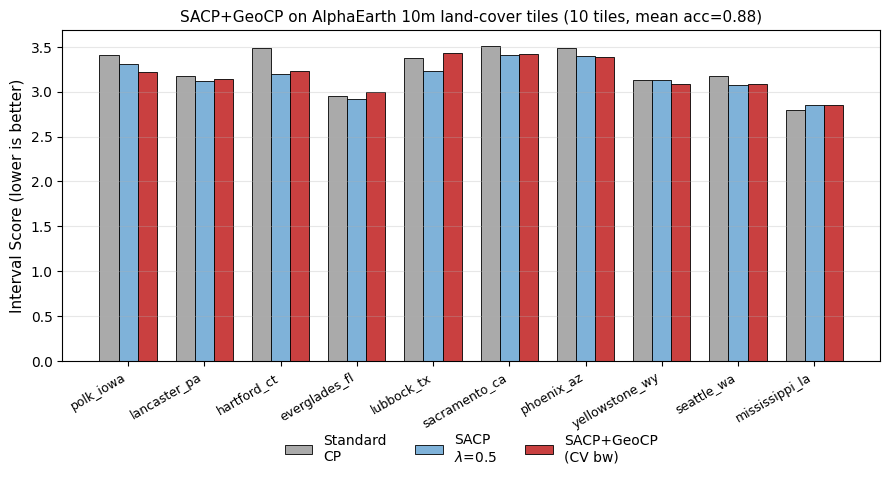

[saved] /content/drive/MyDrive/alphaearth_landcover_pilot_10m/figures/is_bars_per_tile.png


In [ ]:
# Bar chart: IS per tile, 3 methods side by side (10m pilot only has 1 SACP λ)
import matplotlib.pyplot as plt
import numpy as np

methods = ['std_is', 'sacp05_is', 'geocp_is']
labels  = ['Standard\nCP', 'SACP\n$\\lambda$=0.5', 'SACP+GeoCP\n(CV bw)']
colors  = ['#aaaaaa', '#7fb2d9', '#c94040']

fig, ax = plt.subplots(figsize=(max(8, len(df)*0.9), 5))
x = np.arange(len(df))
w = 0.25
for i, (m, lbl, clr) in enumerate(zip(methods, labels, colors)):
    ax.bar(x + (i-1)*w, df[m].values, w, label=lbl, color=clr,
           edgecolor='black', lw=0.6)

ax.set_xticks(x)
ax.set_xticklabels(df['tile'], rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Interval Score (lower is better)', fontsize=11)
ax.set_title(f'SACP+GeoCP on AlphaEarth 10m land-cover tiles ({len(df)} tiles, '
              f'mean acc={df.acc.mean():.2f})', fontsize=11)
ax.legend(ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.18),
           fontsize=10, frameon=False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/is_bars_per_tile.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'[saved] {FIG_DIR}/is_bars_per_tile.png')

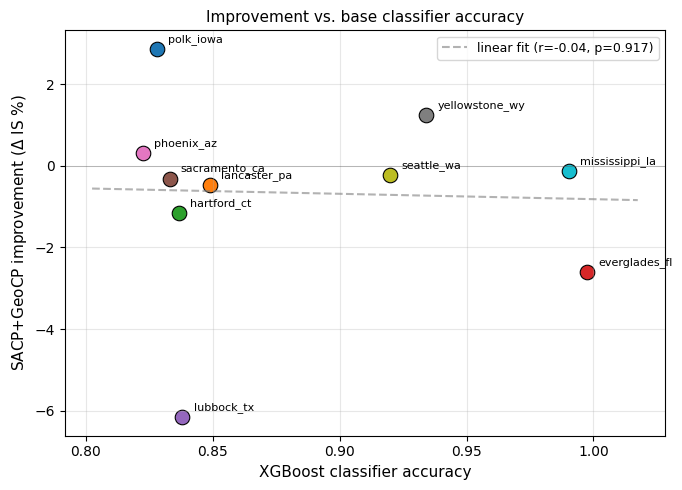

[saved] /content/drive/MyDrive/alphaearth_landcover_pilot_10m/figures/acc_vs_improvement.png


In [ ]:
# Accuracy vs SACP+GeoCP improvement scatter (analog of HSI paper Figure 2)
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

if len(df) >= 3:
    fig, ax = plt.subplots(figsize=(7, 5))
    accs = df['acc'].values
    imps = (df['sacp05_is'].values - df['geocp_is'].values) / df['sacp05_is'].values * 100
    for i, row in df.iterrows():
        ax.scatter(row['acc'], imps[i], s=110, edgecolor='black', lw=0.8)
        ax.annotate(row['tile'], (row['acc'], imps[i]),
                    textcoords='offset points', xytext=(8, 5), fontsize=8)
    if len(np.unique(accs)) >= 2:
        r, p = stats.pearsonr(accs, imps)
        slope, intercept = np.polyfit(accs, imps, 1)
        xs = np.linspace(accs.min()-0.02, accs.max()+0.02, 50)
        ax.plot(xs, slope*xs+intercept, '--', color='gray', alpha=0.6,
                label=f'linear fit (r={r:.2f}, p={p:.3f})')
        ax.legend(fontsize=9)
    ax.axhline(0, color='k', lw=0.5, alpha=0.3)
    ax.set_xlabel('XGBoost classifier accuracy', fontsize=11)
    ax.set_ylabel('SACP+GeoCP improvement ($\\Delta$ IS %)', fontsize=11)
    ax.set_title('Improvement vs. base classifier accuracy', fontsize=11)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/acc_vs_improvement.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'[saved] {FIG_DIR}/acc_vs_improvement.png')
else:
    print(f'Need >=3 tiles for the scatter plot, have {len(df)}')


## 7b. Diagnostics — why does CV keep picking the largest bandwidth?

The 10m pilot results showed that for **10/10 tiles** the 5-fold CV on the calibration subsample picked `bw ∈ {300, 1000}` — i.e. the top of the grid. This means the GeoCP local threshold is collapsing toward a global threshold. Two diagnostics to confirm this is signal-absence (not a bug):

1. **CV selection curves** (free — reads `cv_is_mean` already saved in every checkpoint). If CV-IS is monotone-decreasing in `bw` up to the top of the grid, CV genuinely prefers global.
2. **Test-set bw sweep on polk_iowa + Moran's I of the APS score**. Re-trains XGBoost for one tile, sweeps `bw ∈ {30, 100, 300, 1000, ∞}` on the held-out test set, and measures residual spatial autocorrelation of the non-conformity score.

If Moran's I of the smoothed APS score is ≈ 0, it means the SACP step has already drained the spatial structure out of the score, leaving nothing for GeoCP's geographic kernel to exploit — which is exactly what a negative result for GeoCP on GeoFM features would look like.

--- mean inner-CV IS per (tile, bw) ---
bw               3      5      10     30     100    300    1000
tile                                                           
everglades_fl   9.577  8.251  5.225  3.162  2.934  2.877  2.884
hartford_ct     9.790  8.398  5.438  3.645  3.329  3.268  3.278
lancaster_pa    9.691  8.387  5.409  3.510  3.221  3.197  3.203
lubbock_tx      9.682  8.318  5.538  3.426  3.201  3.189  3.197
mississippi_la  9.557  8.086  5.074  3.097  2.987  2.923  2.911
phoenix_az      9.710  8.284  5.459  3.492  3.286  3.253  3.255
polk_iowa       9.580  8.236  5.577  3.538  3.324  3.263  3.284
sacramento_ca   9.826  8.366  5.485  3.565  3.281  3.201  3.244
seattle_wa      9.579  8.064  5.309  3.249  3.038  2.969  3.003
yellowstone_wy  9.582  8.068  5.346  3.268  3.060  3.034  3.014


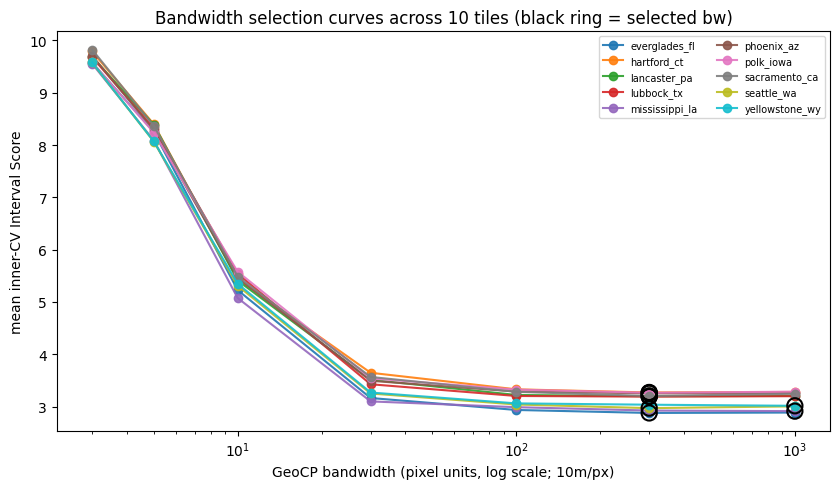

Saved /content/drive/MyDrive/alphaearth_landcover_pilot_10m/figures/bw_selection_curves.png


In [34]:
# Diagnostic (a): CV selection curves — reads cv_is_mean from every checkpoint
import os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rows = []
for tk in TILES.keys():
    p = f'{CKPT_DIR}/{tk}_seed0.pkl'
    if not os.path.exists(p):
        continue
    r = pickle.load(open(p, 'rb'))
    cvm = r['sacp_geocp']['cv_is_mean']
    picked = int(r['sacp_geocp']['bw'])
    for bw, v in cvm.items():
        rows.append({'tile': tk, 'bw': int(bw),
                     'cv_is_mean': float(v), 'picked': int(bw) == picked})
df_cv = pd.DataFrame(rows)
pivot = df_cv.pivot(index='tile', columns='bw', values='cv_is_mean').round(3)
print('--- mean inner-CV IS per (tile, bw) ---')
print(pivot.to_string())

# Plot
fig, ax = plt.subplots(figsize=(8.5, 5.0))
for tk, g in df_cv.groupby('tile'):
    g = g.sort_values('bw')
    ax.plot(g['bw'], g['cv_is_mean'], marker='o', label=tk, alpha=0.9)
    gp = g[g['picked']]
    if len(gp):
        ax.scatter(gp['bw'], gp['cv_is_mean'], s=120, facecolor='none',
                   edgecolor='black', linewidth=1.5, zorder=5)
ax.set_xscale('log')
ax.set_xlabel('GeoCP bandwidth (pixel units, log scale; 10m/px)')
ax.set_ylabel('mean inner-CV Interval Score')
ax.set_title('Bandwidth selection curves across 10 tiles (black ring = selected bw)')
ax.legend(fontsize=7, loc='best', ncol=2)
plt.tight_layout()
out = f'{FIG_DIR}/bw_selection_curves.png'
plt.savefig(out, dpi=160)
plt.show()
print('Saved', out)

In [35]:
# Diagnostic (b): deep test-set bw sweep + Moran's I on polk_iowa
# Re-trains XGBoost for one tile (~1 min). Does NOT overwrite checkpoints.
import os, time
import numpy as np
import xgboost as xgb
from collections import Counter
from sklearn.model_selection import train_test_split
from scipy.spatial.distance import cdist
from scipy.signal import convolve2d

from geocp_rs.core import aps_scores, conformal_quantile, weighted_quantile
from geocp_rs.sacp import sacp_smooth
from geocp_rs.metrics import interval_score, coverage_and_size

TK   = 'polk_iowa'
SEED = 0
ALPHA = 0.1
LMD   = 0.5
MAX_CAL  = 5000
MAX_TEST = 10000

arr = np.load(f'{TILE_DIR}/{TK}.npz')
emb, label = arr['emb'], arr['label']
H, W, _ = emb.shape
N = H * W
flat_label = label.ravel()
X_flat = emb.reshape(N, 64)

labeled_idx = np.where(flat_label > 0)[0]
y_raw = flat_label[labeled_idx]
counts = Counter(y_raw.tolist())
rare = [c for c, cnt in counts.items() if cnt < 100]
keep = ~np.isin(y_raw, rare)
labeled_idx = labeled_idx[keep]; y_raw = y_raw[keep]
X_lab = X_flat[labeled_idx]
classes = sorted(np.unique(y_raw).tolist())
K = len(classes)
cls_remap = {c: i for i, c in enumerate(classes)}
y = np.array([cls_remap[v] for v in y_raw])

idx_pos = np.arange(len(y))
idx_tr, idx_tmp = train_test_split(idx_pos, train_size=0.6, random_state=SEED*100+42, stratify=y)
idx_ca, idx_te  = train_test_split(idx_tmp, test_size=0.5,  random_state=SEED*100+42, stratify=y[idx_tmp])

print(f'{TK}: training XGBoost on {len(idx_tr)} pixels …')
t0 = time.time()
model = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    objective='multi:softprob', num_class=K,
    tree_method='hist', random_state=SEED*100+42, verbosity=0)
model.fit(X_lab[idx_tr], y[idx_tr])
probs_ca = model.predict_proba(X_lab[idx_ca])
probs_te = model.predict_proba(X_lab[idx_te])
print(f'  done in {time.time()-t0:.0f}s')

rng = np.random.RandomState(SEED*100+42)
cal_all  = aps_scores(probs_ca, rng=rng)
test_all = aps_scores(probs_te, rng=rng)

cal_flat_idx  = labeled_idx[idx_ca]
test_flat_idx = labeled_idx[idx_te]

# SACP smoothing on the full grid
score_map = np.zeros((N, K), dtype=np.float64)
score_map[cal_flat_idx]  = cal_all
score_map[test_flat_idx] = test_all
valid_idx = np.concatenate([cal_flat_idx, test_flat_idx])
fused = sacp_smooth(score_map, H, W, valid_idx, lmd=LMD)

fcu = np.array([fused[cal_flat_idx[e], int(y[idx_ca[e]])] for e in range(len(idx_ca))])
ftu = fused[test_flat_idx]

# Pre-SACP APS score at the true class (for a vs-after comparison)
cal_raw_true  = np.array([cal_all[e, int(y[idx_ca[e]])] for e in range(len(idx_ca))])
test_raw_true = np.array([test_all[e, int(y[idx_te[e]])] for e in range(len(idx_te))])

# Stratified subsample (same seed scheme as run_one_tile)
def _stratified_sub(indices, labels, n, seed_):
    if n >= len(indices): return indices
    uniq, per_cls_counts = np.unique(labels, return_counts=True)
    per_cls_n = np.maximum(1, (n * per_cls_counts / per_cls_counts.sum()).astype(int))
    rng_sub = np.random.RandomState(seed_)
    out = []
    for c, nc in zip(uniq, per_cls_n):
        pool = np.where(labels == c)[0]
        out.append(pool if len(pool) <= nc else rng_sub.choice(pool, size=nc, replace=False))
    return np.concatenate(out)

sub_ca = _stratified_sub(np.arange(len(idx_ca)), y[idx_ca], MAX_CAL,  SEED*100+43)
sub_te = _stratified_sub(np.arange(len(idx_te)), y[idx_te], MAX_TEST, SEED*100+43)
y_te_sub = y[idx_te][sub_te]
ftu_sub  = ftu[sub_te]
fcu_sub  = fcu[sub_ca]
coords_ca_sub = np.stack([cal_flat_idx[sub_ca] // W, cal_flat_idx[sub_ca] % W], 1).astype(float)
coords_te_sub = np.stack([test_flat_idx[sub_te] // W, test_flat_idx[sub_te] % W], 1).astype(float)

# ---- (i) test-set bw sweep, including bw = ∞ (global quantile) ----
print('\n--- test-set bw sweep (polk_iowa, held-out test subsample) ---')
d_final = cdist(coords_te_sub, coords_ca_sub)
sweep_rows = []
for bw in [30, 100, 300, 1000, np.inf]:
    if np.isinf(bw):
        q = conformal_quantile(fcu_sub, ALPHA)
        ps = [np.where(ftu_sub[j] < q)[0].tolist() for j in range(len(sub_te))]
    else:
        ps = []
        for j in range(len(sub_te)):
            log_w = -0.5 * (d_final[j] / bw) ** 2
            log_w -= log_w.max()
            w = np.exp(log_w)
            qj = weighted_quantile(fcu_sub, w, ALPHA)
            ps.append(np.where(ftu_sub[j] < qj)[0].tolist())
    cov, sz = coverage_and_size(ps, y_te_sub)
    is_ = interval_score(ps, y_te_sub, ALPHA)
    sweep_rows.append((str(bw), cov, sz, is_))
    print(f'  bw={str(bw):>5}  cov={cov:.3f}  size={sz:.3f}  IS={is_:.3f}')

# ---- (ii) Moran's I on the APS non-conformity score (before and after SACP) ----
def morans_I_sparse_grid(values_at_idx, flat_idx, H, W):
    """8-neighbor Moran's I on an HxW grid where only a subset of pixels is observed.

    values_at_idx: (M,) score at each observed pixel
    flat_idx:      (M,) their flat (row*W + col) indices
    """
    S = np.full((H, W), np.nan)
    S.flat[flat_idx] = values_at_idx
    mask = ~np.isnan(S)
    mean = np.nanmean(S)
    Sm = np.where(mask, S - mean, 0.0)
    kernel = np.ones((3, 3)); kernel[1, 1] = 0.0
    nbr_sum = convolve2d(Sm, kernel, mode='same', boundary='fill', fillvalue=0.0)
    nbr_cnt = convolve2d(mask.astype(float), kernel, mode='same', boundary='fill', fillvalue=0.0)
    num = float((Sm[mask] * nbr_sum[mask]).sum())
    den = float((Sm[mask] ** 2).sum())
    W_sum = float(nbr_cnt[mask].sum())
    Nm = int(mask.sum())
    if den == 0 or W_sum == 0:
        return float('nan'), Nm
    return (Nm / W_sum) * (num / den), Nm

I_raw, Nraw   = morans_I_sparse_grid(test_raw_true, test_flat_idx, H, W)
I_smooth, Nsm = morans_I_sparse_grid(
    np.array([fused[test_flat_idx[e], int(y[idx_te[e]])] for e in range(len(idx_te))]),
    test_flat_idx, H, W)
print(f'\n--- Moran\'s I of APS non-conformity score (8-neighbor) on polk_iowa test grid ---')
print(f'  raw   (pre-SACP)  : I = {I_raw:+.4f}   (N = {Nraw})')
print(f'  smooth (post-SACP): I = {I_smooth:+.4f}   (N = {Nsm})')
print('\nInterpretation:')
print('  Large raw I  + small smooth I  → SACP drained the spatial structure;')
print('                                    GeoCP has nothing left to exploit →')
print('                                    CV prefers bw → ∞ (consistent with our pilot).')
print('  Small raw I already            → AlphaEarth features were never spatially')
print('                                    structured at 10m for this task.')
print('  Large I in both                → GeoCP *should* help; if it doesn\'t, there\'s a bug.')

polk_iowa: training XGBoost on 819414 pixels …
  done in 78s

--- test-set bw sweep (polk_iowa, held-out test subsample) ---
  bw=   30  cov=0.894  size=1.300  IS=3.429
  bw=  100  cov=0.902  size=1.294  IS=3.257
  bw=  300  cov=0.904  size=1.290  IS=3.217
  bw= 1000  cov=0.903  size=1.285  IS=3.233
  bw=  inf  cov=0.902  size=1.284  IS=3.238

--- Moran's I of APS non-conformity score (8-neighbor) on polk_iowa test grid ---
  raw   (pre-SACP)  : I = +0.0779   (N = 273139)
  smooth (post-SACP): I = +0.3781   (N = 273139)

Interpretation:
  Large raw I  + small smooth I  → SACP drained the spatial structure;
                                    GeoCP has nothing left to exploit →
                                    CV prefers bw → ∞ (consistent with our pilot).
  Small raw I already            → AlphaEarth features were never spatially
                                    structured at 10m for this task.
  Large I in both                → GeoCP *should* help; if it doesn't, there's a bug.


## 8. Optional — package & download results

In [ ]:
import shutil

zip_path = '/content/alphaearth_landcover_results.zip'
shutil.make_archive(zip_path[:-4], 'zip', WORK_DIR)
print(f'Bundle: {zip_path}  ({os.path.getsize(zip_path)//1024} KB)')

try:
    from google.colab import files
    files.download(zip_path)
except Exception as e:
    print(f'(auto-download skipped: {e})')
    print(f'All artifacts live at {WORK_DIR} on Drive')


Bundle: /content/alphaearth_landcover_results.zip  (882052 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>